# Calcul de Voile de Contreventement — RPA 2024

**Références :** RPA 2024 §7.7 · BAEL91 mod99  
**Moteur de calcul :** `engine.py` + `concreteproperties 0.7`

---
## Imports & configuration

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Engine lives in the same folder as this notebook
from engine import (
    WallGeometry, Materials, LoadCombo, RebarConfig,
    run_all, STANDARD_DIAMETERS,
)

# Plot style — clean, readable
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F7F4',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
})

# Helper — coloured verdict display
def verdict(ok: bool, msg_ok: str, msg_fail: str):
    colour = '#1B5E20' if ok else '#B71C1C'
    bg     = '#E8F5E9' if ok else '#FFEBEE'
    icon   = '✅' if ok else '❌'
    display(HTML(
        f'<div style="background:{bg};border-left:5px solid {colour};'
        f'padding:0.6rem 1rem;border-radius:0 6px 6px 0;'
        f'font-size:1rem;font-weight:600;color:{colour};margin:6px 0">'
        f'{icon}&nbsp; {msg_ok if ok else msg_fail}</div>'
    ))

print('✔  Imports OK')
print(f'   Diamètres standard disponibles : {STANDARD_DIAMETERS} mm')

✔  Imports OK
   Diamètres standard disponibles : [8, 10, 12, 14, 16, 20, 25, 32] mm


---
## Données d'entrée  ✏️

> **C'est la seule cellule à modifier.** Toutes les autres lisent depuis ces variables.

In [3]:
# ═══════════════════════════════════════════════════════════════════
# GÉOMÉTRIE DU VOILE
# ═══════════════════════════════════════════════════════════════════
geom = WallGeometry(
    lw    =  1.20,   # longueur du voile [m]
    bw    =  0.3,   # épaisseur [m]
    hw    = 30.60,  # hauteur totale de la structure [m]
    he    =  3.06,   # hauteur libre de niveau [m]
    cover = 30.0,   # enrobage [mm]
)

# ═══════════════════════════════════════════════════════════════════
# MATÉRIAUX
# ═══════════════════════════════════════════════════════════════════
mat = Materials(
    fc28 = 30.0,     # résistance béton [MPa]  — valeurs courantes: 25, 30, 35
    fyk  = 500.0,    # limite élastique acier [MPa] — FeE400 ou FeE500
)

# ═══════════════════════════════════════════════════════════════════
# COMBINAISONS DE CHARGES (depuis ETABS — Pier Forces)
# Format : LoadCombo(label, N_Ed [kN], M_base [kN·m], M_top [kN·m])
# N_Ed négatif = compression (convention ETABS)
# ═══════════════════════════════════════════════════════════════════
combos = [
    LoadCombo('ELU-Ex+', N_ed=-2700.0, M_base=1250.0, M_top=750.0),
    # LoadCombo('ELU-Ex-', N_ed=-1800.0, M_base=3600.0, M_top= 950.0),
    # LoadCombo('ELU-Ey+', N_ed=-3100.0, M_base=3900.0, M_top=1050.0),
    # Ajouter autant de combinaisons que nécessaire :
    # LoadCombo('ELU-Ey-', N_ed=-2800.0, M_base=3700.0, M_top=980.0),
]

# ═══════════════════════════════════════════════════════════════════
# CONFIGURATIONS D'ARMATURES
# RebarConfig(nom, boundary_dia, boundary_n, web_dia, web_spacing)
#   boundary_dia : Ø barres élément de rive [mm]
#   boundary_n   : nombre de barres PAR FACE par élément de rive
#   web_dia      : Ø barres d'âme [mm]
#   web_spacing  : espacement c/c barres d'âme [mm]
# ═══════════════════════════════════════════════════════════════════
configs = [
    # RebarConfig('C1 — Critique', boundary_dia=32, boundary_n=6, web_dia=20, web_spacing=100),
    # RebarConfig('C2 — Transition', boundary_dia=32, boundary_n=6, web_dia=16, web_spacing=100),
    RebarConfig('C3 — Moyenne', boundary_dia=20, boundary_n=7, web_dia=16, web_spacing=50),
    RebarConfig('C4 — Courant', boundary_dia=25, boundary_n=7, web_dia=20, web_spacing=50),
    # Exemples supplémentaires :
    # RebarConfig('C4 — Sommet    T10', boundary_dia=10, boundary_n=3,
    #             web_dia=10, web_spacing=300),
    # RebarConfig('C5 — Renforcé  T25', boundary_dia=25, boundary_n=6,
    #             web_dia=12, web_spacing=150),
]

# ═══════════════════════════════════════════════════════════════════
# AFFECTATION NIVEAU → CONFIGURATION
# {numéro_niveau: 'nom_config'}  — doit couvrir tous les niveaux
# Les niveaux non listés héritent de la config du niveau inférieur
# ═══════════════════════════════════════════════════════════════════
storey_map = {
    1: 'C4 — Courant',   
    2: 'C4 — Courant',   
    3: 'C4 — Courant',
    4: 'C4 — Courant',
    5: 'C4 — Courant',   
    6: 'C4 — Courant',
    7: 'C4 — Courant',
    8: 'C3 — Moyenne'
    
}

# ── Récapitulatif des paramètres dérivés ──────────────────────────
print(f'Voile  : lw={geom.lw:.2f} m  bw={geom.bw:.2f} m  hw={geom.hw:.1f} m')
print(f'Niveaux: {geom.n_storeys}  |  he={geom.he:.2f} m')
print(f'hcr    : {geom.hcr:.2f} m  →  {geom.n_crit} niveau(x) critique(s)')
print(f'lc     : {geom.lc*1000:.0f} mm  (éléments de rive)')
print(f'Béton  : C{int(mat.fc28)}  Ec={mat.Ec:.0f} MPa')
print(f'Acier  : FeE{int(mat.fyk)}')
print(f'Combos : {len(combos)}')
print(f'Configs: {len(configs)}')

Voile  : lw=1.20 m  bw=0.30 m  hw=30.6 m
Niveaux: 10  |  he=3.06 m
hcr    : 5.10 m  →  2 niveau(x) critique(s)
lc     : 450 mm  (éléments de rive)
Béton  : C30  Ec=34180 MPa
Acier  : FeE500
Combos : 1
Configs: 2


---
## Phase 1 : Conformité géométrique (RPA 2024 §7.7.1)

In [4]:
from engine import run_phase1

p1 = run_phase1(geom, mat, combos)

# ── Géométrie ─────────────────────────────────────────────────────
print('═'*55)
print('PHASE 1 — Conformité géométrique')
print('═'*55)
print(f'  bw = {p1.bw*100:.0f} cm  ≥  bw_min = {p1.bw_min*100:.0f} cm'
      f'  →  {"OK" if p1.bw_ok else "FAIL"}')
print(f'  lw = {p1.lw:.2f} m  ≥  lw_min = {p1.lw_min:.2f} m'
      f'  →  {"OK" if p1.lw_ok else "FAIL"}')
print(f'  hcr = max(lw, hw/6) = {p1.hcr:.2f} m  →  {p1.n_crit} niveau(x) critique(s)')
print(f'  lc  = max(0.15·lw, 1.5·bw) = {p1.lc*1000:.0f} mm')

verdict(
    p1.bw_ok and p1.lw_ok,
    'Géométrie conforme RPA 2024 §7.7.1',
    'Géométrie NON conforme — corriger bw ou lw',
)

# ── Effort normal réduit νd ────────────────────────────────────────
print()
nu_df = pd.DataFrame([{
    'Combinaison':        c['label'],
    'N_Ed [kN]':          c['label'],  # placeholder
    'νd = |Ned|/(bw·lw·fc28)': round(c['nu_d'], 4),
    'Limite':             0.40,
    'Statut':             '✅ OK' if c['ok'] else '❌ > 0.40',
} for c in p1.nu_d_checks])

# Patch in actual N_Ed values
for i, c in enumerate(combos):
    nu_df.loc[i, 'N_Ed [kN]'] = c.N_ed

display(nu_df.style
    .map(lambda v: 'color:#B71C1C;font-weight:bold'
              if v == '❌ > 0.40' else '', subset=['Statut'])
    .format({'νd = |Ned|/(bw·lw·fc28)': '{:.4f}', 'N_Ed [kN]': '{:.0f}'})
    .set_caption('Vérification effort normal réduit')
    .hide(axis='index')
)

═══════════════════════════════════════════════════════
PHASE 1 — Conformité géométrique
═══════════════════════════════════════════════════════
  bw = 30 cm  ≥  bw_min = 15 cm  →  OK
  lw = 1.20 m  ≥  lw_min = 1.20 m  →  OK
  hcr = max(lw, hw/6) = 5.10 m  →  2 niveau(x) critique(s)
  lc  = max(0.15·lw, 1.5·bw) = 450 mm


TypeError: Invalid value '-2700.0' for dtype 'str'. Value should be a string or missing value, got 'float' instead.

---
## Phase 2 : Enveloppe des moments fléchissants (§7.7.4)

═══════════════════════════════════════════════════════
PHASE 2 — Enveloppe des moments
═══════════════════════════════════════════════════════


Niveau,z [m],Menv ELU-Ex+ [kN·m],Menv max [kN·m]
1,3.1,1250.0,1250.0
2,6.1,1230.0,1230.0
3,9.2,1170.0,1170.0
4,12.2,1110.0,1110.0
5,15.3,1050.0,1050.0
6,18.4,990.0,990.0
7,21.4,930.0,930.0
8,24.5,870.0,870.0
9,27.5,810.0,810.0
10,30.6,750.0,750.0


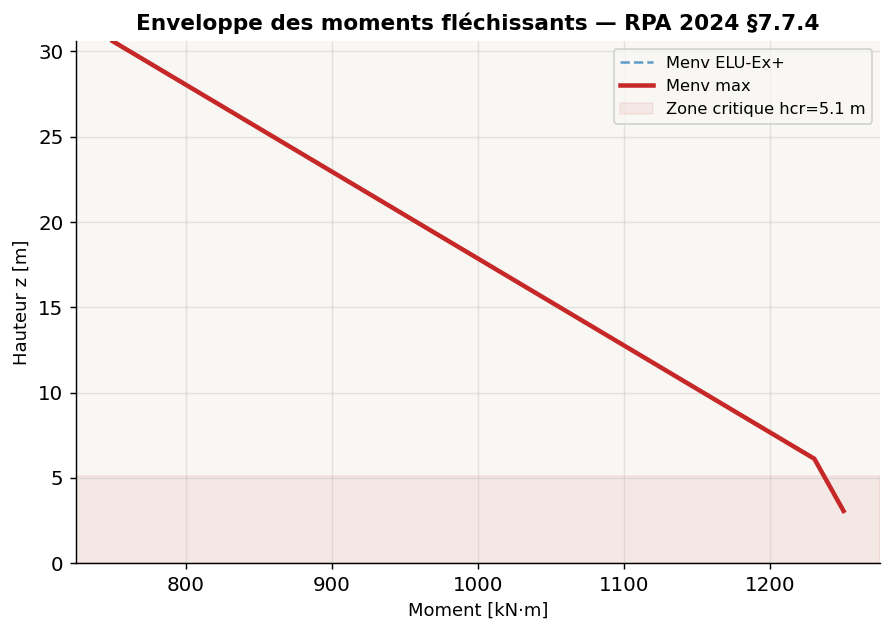

In [5]:
from engine import build_envelope_table

env_table = build_envelope_table(geom, combos)

# Build display DataFrame
rows = []
for r in env_table:
    row = {'Niveau': r['storey'], 'z [m]': r['z_m']}
    for c in combos:
        row[f'Menv {c.label} [kN·m]'] = round(r[f'Menv_{c.label}'], 1)
    row['Menv max [kN·m]'] = round(r['Menv_max'], 1)
    rows.append(row)
env_df = pd.DataFrame(rows)

print('═'*55)
print('PHASE 2 — Enveloppe des moments')
print('═'*55)
display(env_df.style
    .highlight_max(subset=['Menv max [kN·m]'], color='#FFF3CD')
    .format(precision=1)
    .hide(axis='index')
    .set_caption(
        'Menv = |M_base| dans la zone critique (z ≤ hcr), '
        'interpolation linéaire au-dessus'
    )
)

# Quick plot
fig, ax = plt.subplots(figsize=(7, 5))
z_vals = [r['z_m'] for r in env_table]
for c in combos:
    m_vals = [r[f'Menv_{c.label}'] for r in env_table]
    ax.plot(m_vals, z_vals, lw=1.4, alpha=0.7, ls='--', label=f'Menv {c.label}')
ax.plot([r['Menv_max'] for r in env_table], z_vals,
        lw=2.5, color='#C62828', label='Menv max')
ax.axhspan(0, geom.hcr, alpha=0.07, color='#C62828',
           label=f'Zone critique hcr={geom.hcr:.1f} m')
ax.set_xlabel('Moment [kN·m]')
ax.set_ylabel('Hauteur z [m]')
ax.set_title('Enveloppe des moments fléchissants — RPA 2024 §7.7.4')
ax.legend(fontsize=9)
ax.set_ylim(0, geom.hw)
plt.tight_layout()
plt.show()

---
## Phase 3 : Diagrammes N-M (concreteproperties 0.7)

Construction des matériaux…
  Béton  C30 : Ec=34180 MPa, fctm=2.90 MPa
  Acier FeE500 : ElasticPlastic, eps_su=0.05

Calcul des diagrammes N-M…  (quelques secondes par configuration)
  Terminé.


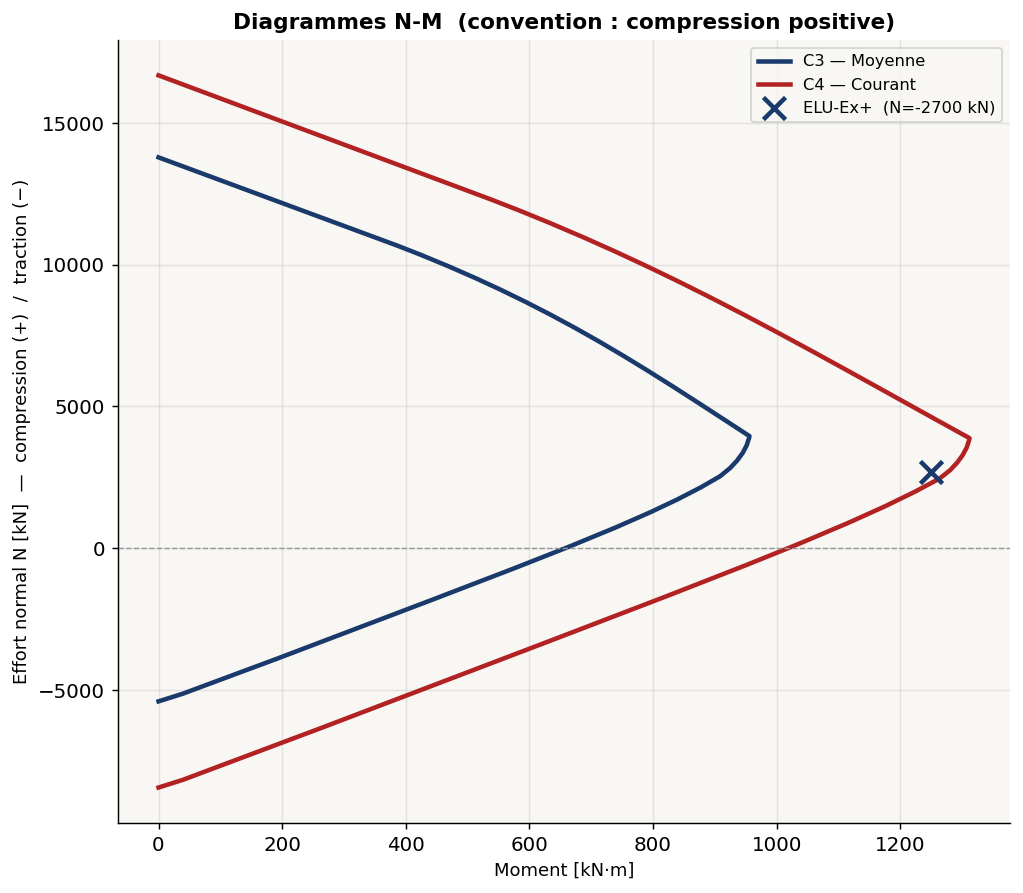


Note : les points ✕ (demande) doivent se trouver DANS le domaine
       délimité par la courbe N-M de leur configuration assignée.


In [6]:
from engine import make_materials, compute_nm_curves

print('Construction des matériaux…')
concrete_mat, steel_mat = make_materials(mat)
print(f'  Béton  C{int(mat.fc28)} : Ec={mat.Ec:.0f} MPa, fctm={mat.fctm:.2f} MPa')
print(f'  Acier FeE{int(mat.fyk)} : ElasticPlastic, eps_su={mat.eps_su}')

print()
print('Calcul des diagrammes N-M…  (quelques secondes par configuration)')
nm_curves = compute_nm_curves(geom, configs, concrete_mat, steel_mat, n_points=30)
print('  Terminé.')

# ── Plot des courbes N-M ──────────────────────────────────────────
PALETTE = ['#1A3A6B','#B22222','#2E7D32','#6A1B9A','#E65100','#00695C']

fig, ax = plt.subplots(figsize=(8, 7))

for (name, data), color in zip(nm_curves.items(), PALETTE):
    mi     = data['mi']
    n_kn   = np.array([r.n   for r in mi.results]) / 1e3
    mx_knm = np.array([r.m_x for r in mi.results]) / 1e6
    ax.plot(mx_knm, n_kn, lw=2.5, color=color, label=name)

# Demand points — flip ETABS sign (compression negative → positive)
for i, c in enumerate(combos):
    N_plot = -c.N_ed   # compression positive, matching concreteproperties
    ax.scatter(c.M_base, N_plot,
               marker='x', s=150, zorder=7, linewidths=2.5,
               color=PALETTE[i % len(PALETTE)],
               label=f'{c.label}  (N={c.N_ed:.0f} kN)')

ax.axhline(0, color='#999', lw=0.8, ls='--')
ax.set_xlabel('Moment [kN·m]')
ax.set_ylabel('Effort normal N [kN]  —  compression (+)  /  traction (−)')
ax.set_title('Diagrammes N-M  (convention : compression positive)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print()
print('Note : les points ✕ (demande) doivent se trouver DANS le domaine')
print('       délimité par la courbe N-M de leur configuration assignée.')

---
## Phase 4 : Vérification niveau par niveau

Niv.,z [m],Zone,Configuration,Menv [kN·m],MR [kN·m],η = Menv/MR,Statut
1,3.060000,🔴 CRITIQUE,C4 — Courant,1250.0,1277.5,0.9785,✅ OK
2,6.120000,🔴 CRITIQUE,C4 — Courant,1230.0,1277.5,0.9628,✅ OK
3,9.180000,🟢 standard,C4 — Courant,1170.0,1277.5,0.9158,✅ OK
4,12.240000,🟢 standard,C4 — Courant,1110.0,1277.5,0.8689,✅ OK
5,15.300000,🟢 standard,C4 — Courant,1050.0,1277.5,0.8219,✅ OK
6,18.360000,🟢 standard,C4 — Courant,990.0,1277.5,0.7749,✅ OK
7,21.420000,🟢 standard,C4 — Courant,930.0,1277.5,0.7280,✅ OK
8,24.480000,🟢 standard,C3 — Moyenne,870.0,917.5,0.9482,✅ OK
9,27.540000,🟢 standard,C3 — Moyenne,810.0,917.5,0.8828,✅ OK
10,30.600000,🟢 standard,C3 — Moyenne,750.0,917.5,0.8174,✅ OK


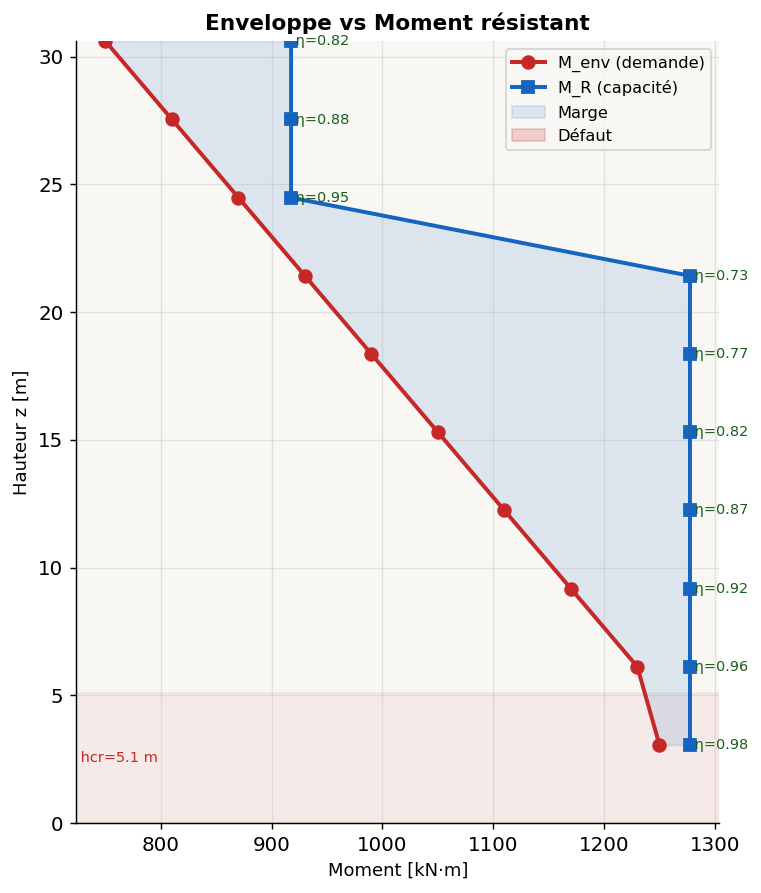

In [7]:
from engine import run_phase4

storeys = run_phase4(env_table, nm_curves, storey_map)

# ── Résultats tableau ─────────────────────────────────────────────
p4_df = pd.DataFrame([{
    'Niv.':          r.storey,
    'z [m]':         round(r.z_m,  2),
    'Zone':          '🔴 CRITIQUE' if r.storey <= p1.n_crit else '🟢 standard',
    'Configuration': r.cfg_name,
    'Menv [kN·m]':   round(r.Menv, 1),
    'MR [kN·m]':     round(r.MR,   1),
    'η = Menv/MR':   round(r.eta,  4),
    'Statut':        '✅ OK' if r.ok else '❌ FAIL',
} for r in storeys])

def colour_eta(val):
    if isinstance(val, float):
        if val <= 0.80: return 'background-color:#C8E6C9'
        if val <= 1.00: return 'background-color:#FFF9C4'
        return 'background-color:#FFCDD2;font-weight:bold'
    return ''

display(p4_df.style
    .map(colour_eta, subset=['η = Menv/MR'])
    .map(lambda v: 'color:#B71C1C;font-weight:bold'
              if v == '❌ FAIL' else '', subset=['Statut'])
    .format({'η = Menv/MR': '{:.4f}', 'Menv [kN·m]': '{:.1f}', 'MR [kN·m]': '{:.1f}'})
    .hide(axis='index')
    .set_caption('η ≤ 0.80 : vert · 0.80 < η ≤ 1.00 : jaune · η > 1.00 : rouge')
)

# ── Verdict global ────────────────────────────────────────────────
all_ok = all(r.ok for r in storeys)
n_fail = sum(1 for r in storeys if not r.ok)
verdict(
    all_ok,
    'TOUS LES NIVEAUX VÉRIFIENT  η ≤ 1.0',
    f'{n_fail} NIVEAU(X) EN DÉFAUT — augmenter les armatures'
)

# ── Plot Menv vs MR sur la hauteur ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 7))
z   = [r.z_m  for r in storeys]
Menv= [r.Menv for r in storeys]
MR  = [r.MR   for r in storeys]

ax.plot(Menv, z, 'o-', color='#C62828', lw=2.2, ms=7, label='M_env (demande)')
ax.plot(MR,   z, 's-', color='#1565C0', lw=2.2, ms=7, label='M_R (capacité)')
ax.fill_betweenx(z, Menv, MR,
                 where=[m <= mr for m, mr in zip(Menv, MR)],
                 alpha=0.12, color='#1565C0', label='Marge')
ax.fill_betweenx(z, Menv, MR,
                 where=[m > mr for m, mr in zip(Menv, MR)],
                 alpha=0.20, color='#C62828', label='Défaut')

for r in storeys:
    c = '#1B5E20' if r.ok else '#B71C1C'
    ax.annotate(f' η={r.eta:.2f}',
                xy=(max(r.Menv, r.MR), r.z_m),
                fontsize=8, color=c, va='center')

ax.axhspan(0, geom.hcr, alpha=0.06, color='#C62828')
ax.text(ax.get_xlim()[0], geom.hcr/2,
        f' hcr={geom.hcr:.1f} m', fontsize=8, color='#C62828', va='center')

ax.set_xlabel('Moment [kN·m]')
ax.set_ylabel('Hauteur z [m]')
ax.set_title('Enveloppe vs Moment résistant')
ax.set_ylim(0, geom.hw)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Phase 5 : Ductilité locale et confinement (§7.7.3)

In [8]:
from engine import run_phase5

# Base config = config du niveau 1 (la plus armée)
base_cfg_name = storey_map.get(1) or storey_map[min(storey_map)]
base_cfg = next(c for c in configs if c.name == base_cfg_name)

p5 = run_phase5(geom, mat, combos, base_cfg)

print('═'*55)
print('PHASE 5 — Ductilité locale & confinement')
print('═'*55)
print(f'  Config de base (niveau 1) : {base_cfg.name}')
print()
print(f'  νd (pied, combo max)  = {p5.nu_d:.4f}   (limite : 0.40)')
print(f'  ρv (armatures âme)    = {p5.rho_v:.5f}')
print(f'  ωv = ρv · fyk / fc28  = {p5.omega_v:.4f}')
print()
print(f'  ωwd requis  ≥  {p5.omega_wd_req:.4f}   (μφ = {p5.mu_phi})')
print(f'  St max      ≤  {p5.St_max:.1f} mm')
print()
print('  Formule RPA 2024 §7.7.3 :')
print('  ωwd ≥ 30·μφ·(νd + ωv)·εsy·(bc/b0) − 0.035')
print(f'      ≥ 30×{p5.mu_phi}×({p5.nu_d:.4f}+{p5.omega_v:.4f})'
      f'×{mat.fyk/mat.Es:.5f}×... = {p5.omega_wd_req:.4f}')

display(HTML(
    f'<div style="background:#FFF8E0;border-left:4px solid #E6A800;'
    f'padding:0.6rem 1rem;border-radius:0 6px 6px 0;margin:8px 0;'
    f'font-size:0.9rem;color:#4A3300">'
    f'<b>⚠️ Confinement éléments de rive :</b> cadres fermés '
    f'espacés <b>St ≤ {p5.St_max:.1f} mm</b> '
    f'sur toute la hauteur h<sub>cr</sub> = {geom.hcr:.2f} m.<br>'
    f'Vérifier séparément ω<sub>wd</sub> ≥ {p5.omega_wd_req:.4f} '
    f'avec le ferraillage transversal retenu.'
    f'</div>'
))

═══════════════════════════════════════════════════════
PHASE 5 — Ductilité locale & confinement
═══════════════════════════════════════════════════════
  Config de base (niveau 1) : C4 — Courant

  νd (pied, combo max)  = 0.2500   (limite : 0.40)
  ρv (armatures âme)    = 0.02094
  ωv = ρv · fyk / fc28  = 0.3491

  ωwd requis  ≥  0.2458   (μφ = 5.0)
  St max      ≤  80.0 mm

  Formule RPA 2024 §7.7.3 :
  ωwd ≥ 30·μφ·(νd + ωv)·εsy·(bc/b0) − 0.035
      ≥ 30×5.0×(0.2500+0.3491)×0.00250×... = 0.2458


---
## Dessins de sections transversales


───────────────────────────────────────────────────────
  C3 — Moyenne
  BE : 7 barres/face × Ø20 mm
  Âme: Ø16 @ 50 mm


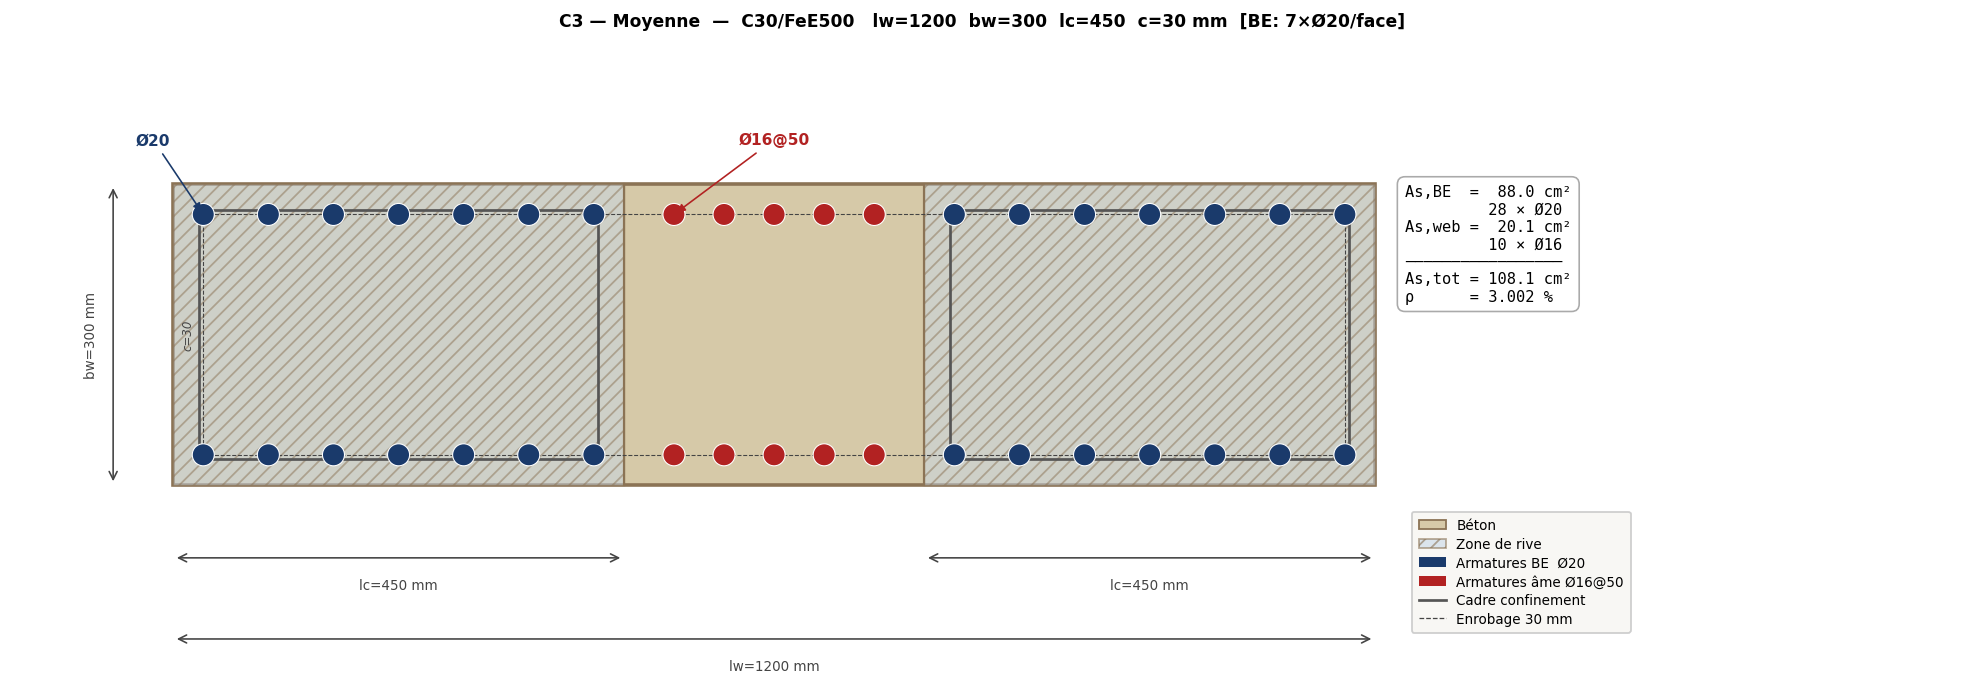

"As,BE [cm²]",(28×Ø20),"As,âme [cm²]",(10×Ø16),"As,total [cm²]",ρ [%],Esp. BE [mm]
87.960000,,20.110000,,108.070000,3.002000,65.000000



───────────────────────────────────────────────────────
  C4 — Courant
  BE : 7 barres/face × Ø25 mm
  Âme: Ø20 @ 50 mm


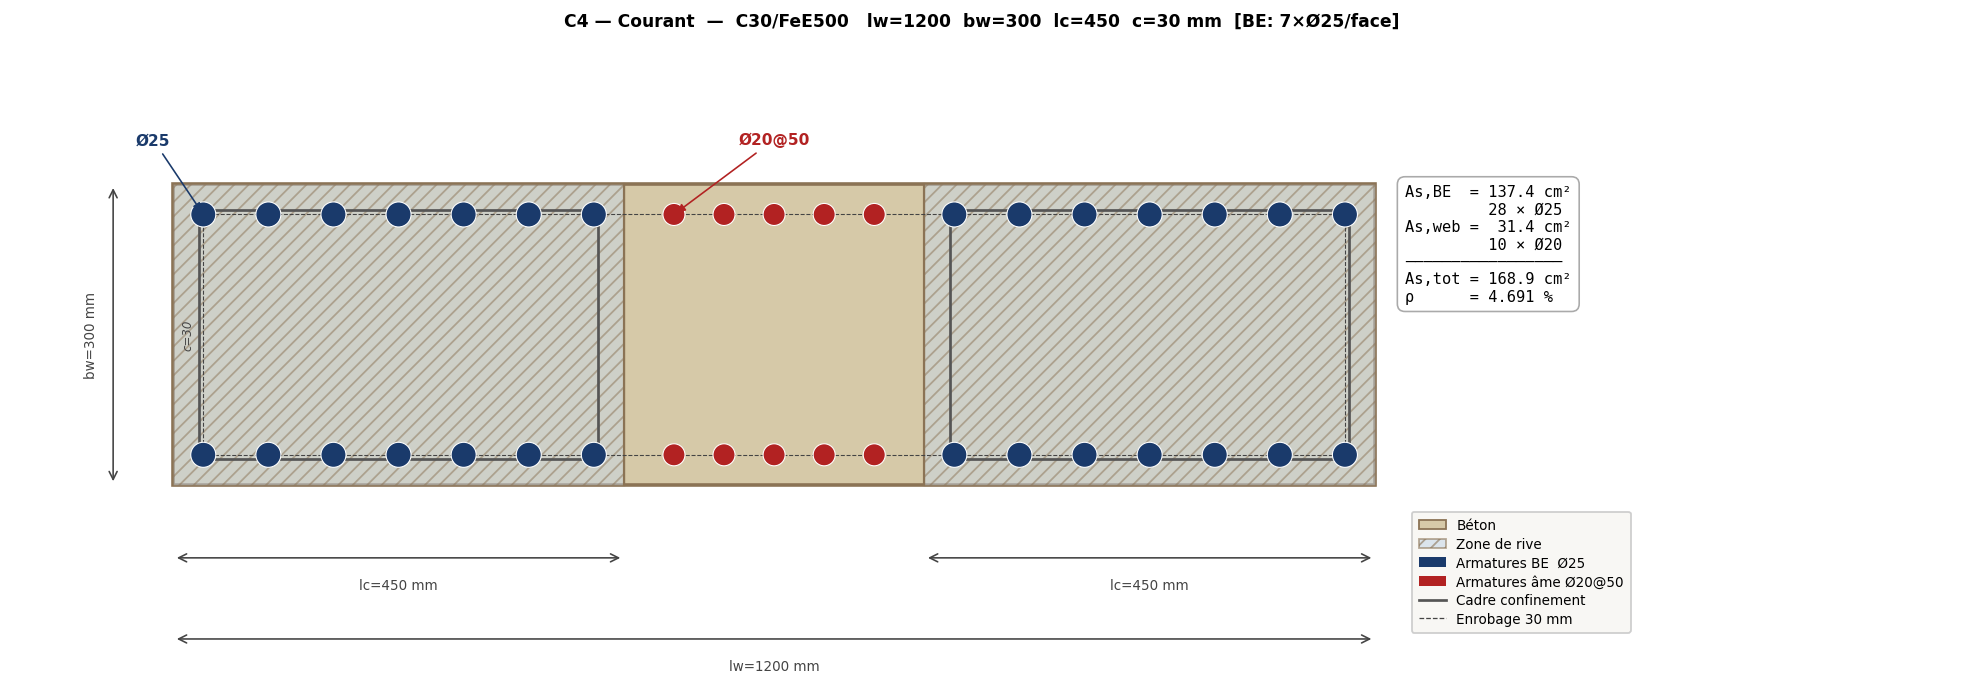

"As,BE [cm²]",(28×Ø25),"As,âme [cm²]",(10×Ø20),"As,total [cm²]",ρ [%],Esp. BE [mm]
137.440000,,31.420000,,168.860000,4.691000,65.000000


In [9]:
from engine import make_section_figure

for cfg in configs:
    print(f'\n{"─"*55}')
    print(f'  {cfg.name}')
    print(f'  BE : {cfg.boundary_n} barres/face × Ø{cfg.boundary_dia} mm')
    print(f'  Âme: Ø{cfg.web_dia} @ {cfg.web_spacing} mm')
    
    fig = make_section_figure(cfg, geom)
    plt.show()

    # Quick stats
    lc_mm   = geom.lc * 1000
    lw_mm   = geom.lw * 1000
    bw_mm   = geom.bw * 1000
    n_be    = 4 * cfg.boundary_n
    web_len = (lw_mm - 2*lc_mm)
    n_web   = max(int(web_len / cfg.web_spacing) - 1, 1) * 2
    A_be    = n_be  * np.pi * cfg.boundary_dia**2 / 4 / 100
    A_web   = n_web * np.pi * cfg.web_dia**2      / 4 / 100
    A_tot   = A_be + A_web
    rho     = A_tot / (lw_mm * bw_mm) * 100**2
    be_spac = (lc_mm - 2*geom.cover) / max(cfg.boundary_n - 1, 1)

    stats = pd.DataFrame([{
        'As,BE [cm²]':   round(A_be,  2),
        f'({n_be}×Ø{cfg.boundary_dia})': '',
        'As,âme [cm²]':  round(A_web, 2),
        f'({n_web}×Ø{cfg.web_dia})': '',
        'As,total [cm²]':round(A_tot, 2),
        'ρ [%]':         round(rho,   3),
        'Esp. BE [mm]':  round(be_spac,1),
    }])
    display(stats.style.hide(axis='index'))

---
## Export des résultats

✔  Excel  → resultats\rpa2024_voile.xlsx
✔  Plot   → resultats\nm_et_enveloppe.png
✔  Section → resultats\section_C3__Moyenne.png
✔  Section → resultats\section_C4__Courant.png

Tous les fichiers sont dans le dossier : ./resultats/


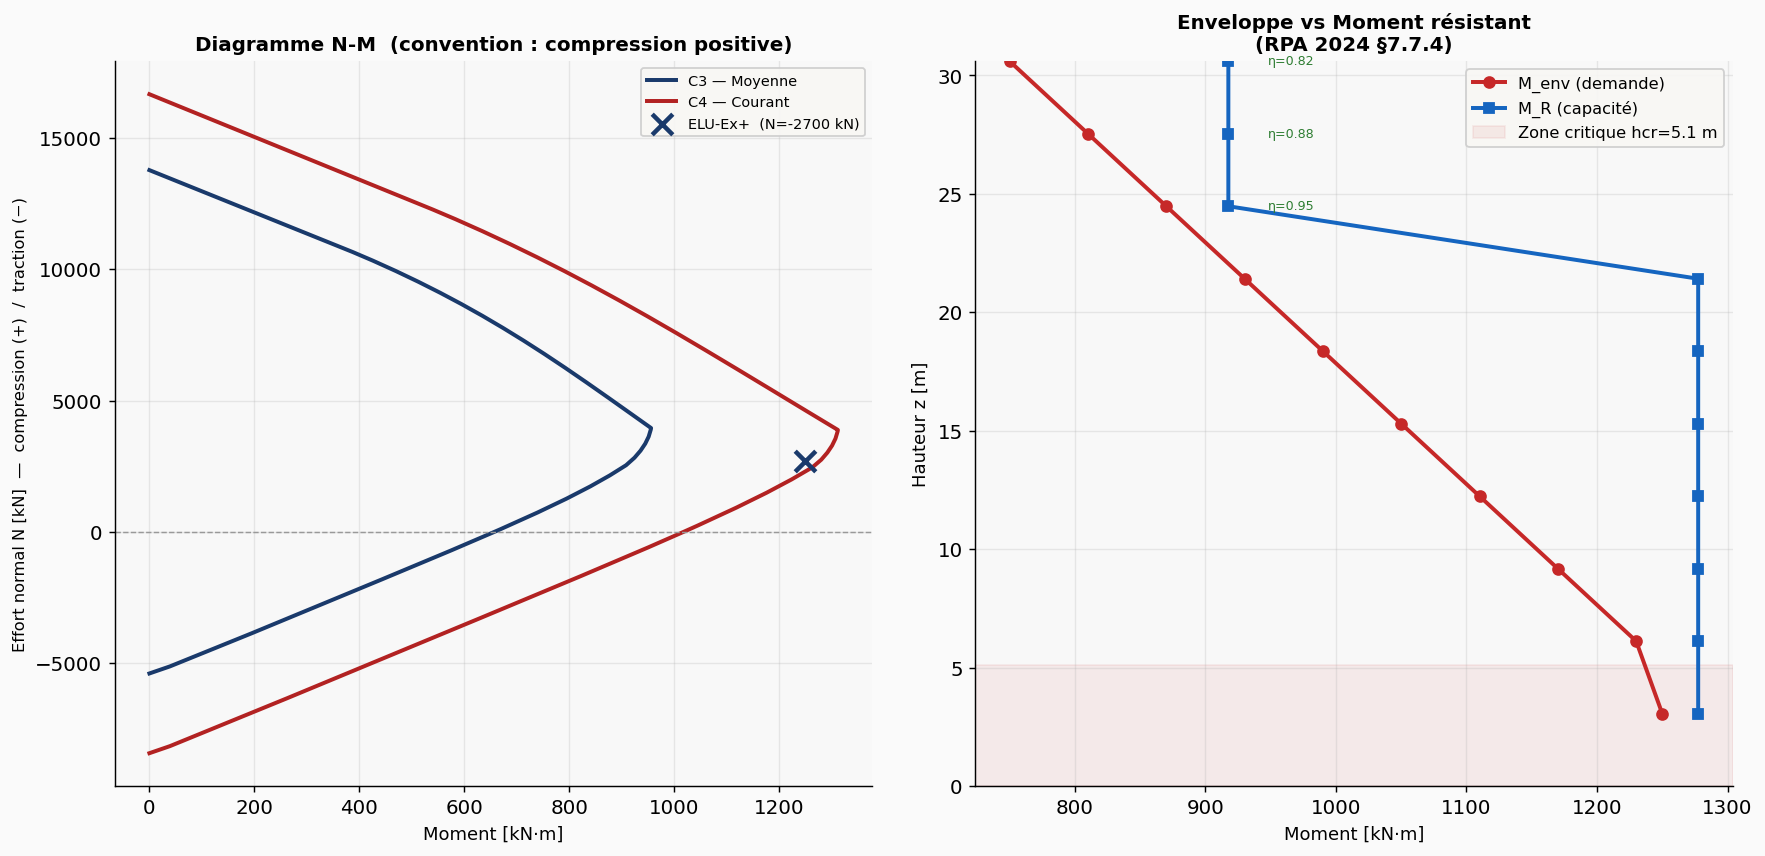

In [138]:
import os
from engine import make_nm_figure

out_dir = 'resultats'
os.makedirs(out_dir, exist_ok=True)

# ── Excel — tous les tableaux en feuilles séparées ────────────────
xlsx_path = os.path.join(out_dir, 'rpa2024_voile.xlsx')
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:

    # Feuille 1 — Paramètres
    params = pd.DataFrame([
        ['lw [m]',  geom.lw],  ['bw [m]',  geom.bw],
        ['hw [m]',  geom.hw],  ['he [m]',  geom.he],
        ['cover [mm]', geom.cover], ['hcr [m]', geom.hcr],
        ['lc [mm]', geom.lc*1000], ['n_crit', geom.n_crit],
        ['fc28 [MPa]', mat.fc28],  ['fyk [MPa]', mat.fyk],
    ], columns=['Paramètre', 'Valeur'])
    params.to_excel(writer, sheet_name='Paramètres', index=False)

    # Feuille 2 — Combinaisons
    pd.DataFrame([{
        'Label': c.label, 'N_Ed [kN]': c.N_ed,
        'M_base [kN·m]': c.M_base, 'M_top [kN·m]': c.M_top
    } for c in combos]).to_excel(writer, sheet_name='Combinaisons', index=False)

    # Feuille 3 — Enveloppe
    env_df.to_excel(writer, sheet_name='Enveloppe', index=False)

    # Feuille 4 — Vérification
    p4_df.to_excel(writer, sheet_name='Vérification', index=False)

    # Feuille 5 — Confinement
    pd.DataFrame([{
        'νd': round(p5.nu_d, 4),
        'ρv': round(p5.rho_v, 6),
        'ωv': round(p5.omega_v, 4),
        'ωwd requis': round(p5.omega_wd_req, 4),
        'St max [mm]': round(p5.St_max, 1),
    }]).to_excel(writer, sheet_name='Confinement', index=False)

print(f'✔  Excel  → {xlsx_path}')

# ── PNG — diagramme N-M + enveloppe ──────────────────────────────
nm_fig = make_nm_figure(nm_curves, combos, storeys, geom)
nm_path = os.path.join(out_dir, 'nm_et_enveloppe.png')
nm_fig.savefig(nm_path, dpi=180, bbox_inches='tight')
print(f'✔  Plot   → {nm_path}')

# ── PNG — sections ────────────────────────────────────────────────
for cfg in configs:
    fig = make_section_figure(cfg, geom)
    safe = cfg.name.replace(' ', '_').replace('—','').replace('/','').strip('_')
    sec_path = os.path.join(out_dir, f'section_{safe}.png')
    fig.savefig(sec_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f'✔  Section → {sec_path}')

print()
print(f'Tous les fichiers sont dans le dossier : ./{out_dir}/')